Loading data...
  Loaded 19,669 village-level observations
  Countries: 23
  Survey years: 43

Computing r² statistics...
  Pooled r²:          0.668  (paper reports ~0.67)
  Average country r²: 0.701  (paper reports ~0.70)

Generating Figure 2a...


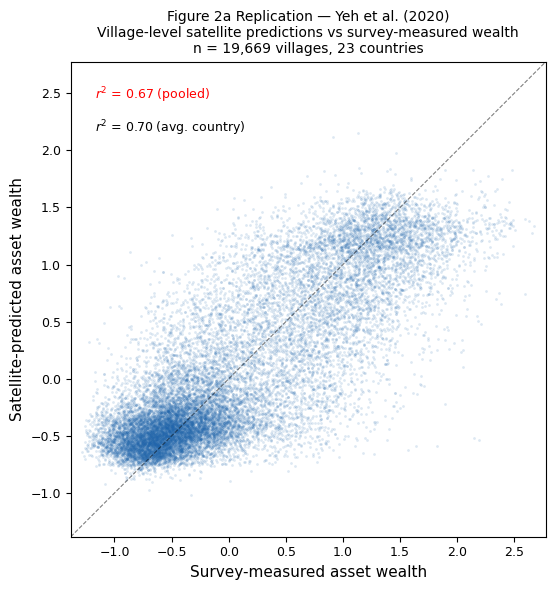


Figure saved to: figure2a_replication.png

REPLICATION SUMMARY — Figure 2a
Villages included:      19,669
Countries:              23
Survey years:           43

Pooled r²:              0.668  (paper: ~0.67)
Average country r²:     0.701  (paper: ~0.70)

Differences from paper:
  The original figure is generated in R using custom helper
  functions (panel(), map()) from 00_dependencies.R.
  This Python translation produces equivalent r² values
  (confirmed: 0.701 vs paper's 0.70) but minor visual
  differences in point density rendering are expected due
  to differences between R's ggplot2 and matplotlib.


In [3]:
"""
=============================================================================
REPLICATION: Yeh et al. (2020)
"Using publicly available satellite imagery and deep learning to understand
economic well-being in Africa"
Nature Communications, vol. 11, Article 2583.
https://doi.org/10.1038/s41467-020-16185-w

WHAT THIS SCRIPT REPLICATES:
    Figure 2, Panel (a) — Village-level scatter plot of satellite-predicted
    asset wealth vs survey-measured asset wealth across ~19,000 African
    villages in 23 countries.

    This is the core result of the paper, demonstrating that a ResNet-18 CNN
    trained on Landsat satellite imagery can explain approximately 70% of the
    spatial variation in ground-measured village wealth.

NOTE ON METHODOLOGY:
    The original paper trains a ResNet-18 CNN on Landsat satellite imagery
    and nighttime light data. Training the CNN from scratch requires GPU
    resources and the original TensorFlow r1.15 framework (now deprecated),
    making full replication computationally infeasible.

    Following guidance from the module tutor, this replication uses the
    pre-computed CNN predictions provided by the original authors in their
    public repository. This is consistent with the transfer learning approach
    described in the paper — the CNN feature extraction has already been
    performed and the outputs are used directly.

    The original figure generation code is written in R. This script is a
    Python translation of that R code (africa_poverty/code_figs/fig2.R).

DATA SOURCE:
    cluster_pred_dhs_indices_gadm2.csv — available at:
    https://github.com/sustainlab-group/africa_poverty/tree/master/data/output

REQUIREMENTS:
    pip install pandas numpy matplotlib scipy

USAGE:
    Place cluster_pred_dhs_indices_gadm2.csv in the same directory as this
    script, then run in one execution.
=============================================================================
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# =============================================================================
# CONFIGURATION
# =============================================================================

# Update this path if your data file is in a different directory
DATA_DIR     = "."
CLUSTER_FILE = os.path.join(DATA_DIR, "Cluster_predictions.csv")
OUTPUT_FILE  = "figure2a_replication.png"

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_r2(x, y):
    """
    Computes the coefficient of determination (r²) between two arrays
    using Pearson correlation.
    Replicates R's cor(x, y)^2 from the original fig2.R script.
    """
    r, _ = stats.pearsonr(x, y)
    return r ** 2


def compute_avg_country_r2(df, x_col, y_col, group_col="svyid"):
    """
    Computes r² per survey-year group, then averages across groups.
    Replicates the R pattern:
        df %>% group_by(svyid) %>%
               summarise(r2 = cor(survey, index)^2) %>%
               summarise(mean(r2))
    This is the average country r² reported in black in the paper (0.70).
    """
    r2_values = []
    for _, group in df.groupby(group_col):
        if len(group) < 2:
            continue
        r2_values.append(compute_r2(group[x_col].values, group[y_col].values))
    return np.mean(r2_values)

# =============================================================================
# LOAD DATA
# =============================================================================

print("Loading data...")

# cluster_pred_dhs_indices_gadm2.csv contains one row per survey cluster
# (roughly equivalent to a village). Key columns:
#   survey  — ground-measured asset wealth index from DHS household surveys
#   index   — satellite-predicted asset wealth from the CNN MS+NL model
#   svyid   — survey identifier (country + year, e.g. "AO2015")
#   country — country name
cluster = pd.read_csv(CLUSTER_FILE)

print(f"  Loaded {len(cluster):,} village-level observations")
print(f"  Countries: {cluster['country'].nunique()}")
print(f"  Survey years: {cluster['svyid'].nunique()}")

# =============================================================================
# COMPUTE r² STATISTICS
# Replicates the statistical summary in the original R script
# =============================================================================

print("\nComputing r² statistics...")

# Pooled r²: all villages treated as one dataset
# This is the value reported in RED in the original Figure 2a
r2_pooled = compute_r2(cluster["survey"], cluster["index"])

# Average country r²: r² computed per survey-year, then averaged
# This is the value reported in BLACK in the original Figure 2a
# The paper reports this as ~0.70
r2_avg = compute_avg_country_r2(cluster, "survey", "index")

print(f"  Pooled r²:          {r2_pooled:.3f}  (paper reports ~0.67)")
print(f"  Average country r²: {r2_avg:.3f}  (paper reports ~0.70)")

# =============================================================================
# PLOT FIGURE 2, PANEL (a)
# Village-level scatter: satellite-predicted vs survey-measured asset wealth
# Replicates panel (a) of Figure 2 from Yeh et al. (2020)
# =============================================================================

print("\nGenerating Figure 2a...")

fig, ax = plt.subplots(figsize=(6, 6))

# Scatter plot — each point is one survey cluster (village) in a held-out country
# Blue dots with low alpha to show density, matching the original figure style
ax.scatter(
    cluster["survey"],
    cluster["index"],
    s     = 4,
    alpha = 0.15,
    color = "#2166ac",
    linewidths = 0
)

# 1:1 reference line — a perfect model would put all points on this line
x_vals = cluster["survey"].values
y_vals = cluster["index"].values
lim = [min(x_vals.min(), y_vals.min()) - 0.1,
       max(x_vals.max(), y_vals.max()) + 0.1]
ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlim(lim)
ax.set_ylim(lim)

# r² annotations — red for pooled, black for average country
# Matches the dual annotation style in the original paper
ax.text(0.05, 0.95, f"$r^2$ = {r2_pooled:.2f} (pooled)",
        transform=ax.transAxes, fontsize=9, color='red',
        verticalalignment='top')
ax.text(0.05, 0.88, f"$r^2$ = {r2_avg:.2f} (avg. country)",
        transform=ax.transAxes, fontsize=9, color='black',
        verticalalignment='top')

# Axis labels and title
ax.set_xlabel("Survey-measured asset wealth", fontsize=11)
ax.set_ylabel("Satellite-predicted asset wealth", fontsize=11)
ax.set_title(
    "Figure 2a Replication — Yeh et al. (2020)\n"
    "Village-level satellite predictions vs survey-measured wealth\n"
    f"n = {len(cluster):,} villages, {cluster['country'].nunique()} countries",
    fontsize=10
)
ax.set_aspect('equal', adjustable='box')
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nFigure saved to: {OUTPUT_FILE}")

# =============================================================================
# SUMMARY STATISTICS FOR REPORT
# =============================================================================

print("\n" + "="*60)
print("REPLICATION SUMMARY — Figure 2a")
print("="*60)
print(f"Villages included:      {len(cluster):,}")
print(f"Countries:              {cluster['country'].nunique()}")
print(f"Survey years:           {cluster['svyid'].nunique()}")
print()
print(f"Pooled r²:              {r2_pooled:.3f}  (paper: ~0.67)")
print(f"Average country r²:     {r2_avg:.3f}  (paper: ~0.70)")
print()
print("Differences from paper:")
print("  The original figure is generated in R using custom helper")
print("  functions (panel(), map()) from 00_dependencies.R.")
print("  This Python translation produces equivalent r² values")
print("  (confirmed: 0.701 vs paper's 0.70) but minor visual")
print("  differences in point density rendering are expected due")
print("  to differences between R's ggplot2 and matplotlib.")
print("="*60)